In [1]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '4'
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['MKL_NUM_THREADS'] = '4'

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import gc
import warnings
from threadpoolctl import threadpool_limits
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/dataset_selection_sans_leger.csv")

print(f"Nombre total d'images : {len(df)}")
print(f"\nRépartition des labels :")
print(df['label'].value_counts())

Nombre total d'images : 6323

Répartition des labels :
label
glaucome    1581
mda         1581
diabete     1581
normaux     1580
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df, test_size=0.1, stratify=df['label'], random_state=42
)

print(f"Train : {len(df_train)}")
print(f"Test  : {len(df_test)}")

classes = sorted(df['label'].unique().tolist())
print(f"Classes : {classes}")

Train : 5690
Test  : 633
Classes : ['diabete', 'glaucome', 'mda', 'normaux']


In [3]:
def crop_black_border(img, thr=10, pad=10):
    """Enlève les bords noirs d'une image (numpy array grayscale ou BGR)."""
    gray = img if len(img.shape) == 2 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = gray > thr
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    y0, y1 = max(0, ys.min() - pad), min(img.shape[0] - 1, ys.max() + pad)
    x0, x1 = max(0, xs.min() - pad), min(img.shape[1] - 1, xs.max() + pad)
    return img[y0:y1+1, x0:x1+1]

def load_image_gray(path):
    """Charge une image en niveaux de gris avec crop des bords noirs."""
    img = np.array(Image.open(path).convert("L"))
    img = crop_black_border(img)
    return img

def augment_image(img):
    """Retourne 5 versions augmentées: 2 rotations + flip H + flip V + contraste."""
    aug = []
    h, w = img.shape[:2]
    for angle in [-15, 15]:
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        aug.append(cv2.warpAffine(img, M, (w, h)))
    aug.append(cv2.flip(img, 1))  # flip horizontal
    aug.append(cv2.flip(img, 0))  # flip vertical
    aug.append(np.clip(img.astype(np.float32) * 1.2 - 15, 0, 255).astype(np.uint8))  # contraste
    return aug

print("Fonctions de prétraitement définies")

Fonctions de prétraitement définies


In [4]:
from skimage.feature import hog

IMG_SIZE = (128, 128)

def extract_hog(image):
    image = cv2.resize(image, IMG_SIZE)
    return hog(image, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), block_norm='L2-Hys')

def extract_pixels(image):
    image = cv2.resize(image, IMG_SIZE)
    return image.flatten().astype(np.float32) / 255.0

print(f"HOG: {extract_hog(np.zeros(IMG_SIZE, dtype=np.uint8)).shape[0]} features")
print(f"Pixels: {IMG_SIZE[0]*IMG_SIZE[1]} features")

HOG: 8100 features
Pixels: 16384 features


In [5]:
X_train_hog, X_train_pixels, y_train = [], [], []

for _, row in tqdm(df_train.iterrows(), total=len(df_train), desc="Train"):
    img = load_image_gray(row['path'])

    X_train_hog.append(extract_hog(img))
    X_train_pixels.append(extract_pixels(img))
    y_train.append(row['label'])

    for aug in augment_image(img):
        X_train_hog.append(extract_hog(aug))
        X_train_pixels.append(extract_pixels(aug))
        y_train.append(row['label'])

X_train_hog = np.array(X_train_hog, dtype=np.float32)   # float32 au lieu de float64
X_train_pixels = np.array(X_train_pixels, dtype=np.float32)
y_train = np.array(y_train)

print(f"X_train_hog:    {X_train_hog.shape}  ({X_train_hog.nbytes/1e9:.2f} GB)")
print(f"X_train_pixels: {X_train_pixels.shape}  ({X_train_pixels.nbytes/1e9:.2f} GB)")
print(f"y_train:        {y_train.shape}")

Train: 100%|██████████| 5690/5690 [09:01<00:00, 10.50it/s]


X_train_hog:    (34140, 8100)  (1.11 GB)
X_train_pixels: (34140, 16384)  (2.24 GB)
y_train:        (34140,)


In [6]:
X_test_hog, X_test_pixels, y_test = [], [], []

for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Test"):
    img = load_image_gray(row['path'])
    X_test_hog.append(extract_hog(img))
    X_test_pixels.append(extract_pixels(img))
    y_test.append(row['label'])

X_test_hog = np.array(X_test_hog)
X_test_pixels = np.array(X_test_pixels, dtype=np.float32)
y_test = np.array(y_test)

print(f"X_test_hog:    {X_test_hog.shape}")
print(f"X_test_pixels: {X_test_pixels.shape}")

Test: 100%|██████████| 633/633 [00:34<00:00, 18.13it/s]

X_test_hog:    (633, 8100)
X_test_pixels: (633, 16384)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler_hog = StandardScaler()
X_train_hog_sc = scaler_hog.fit_transform(X_train_hog)
X_test_hog_sc = scaler_hog.transform(X_test_hog)
del X_train_hog, X_test_hog
gc.collect()

scaler_pix = StandardScaler()
X_train_pix_sc = scaler_pix.fit_transform(X_train_pixels)
X_test_pix_sc = scaler_pix.transform(X_test_pixels)
del X_train_pixels, X_test_pixels
gc.collect()

n_pixel_features = X_train_pix_sc.shape[1]
n_hog_features = X_train_hog_sc.shape[1]

# X_test_combined est petit (621 samples), on le garde pour l'évaluation
X_test_combined = np.hstack([X_test_pix_sc, X_test_hog_sc])
# X_train_combined sera créé à la demande dans la cell PCA+HOG

print(f"HOG scaled:    {X_train_hog_sc.shape}  ({X_train_hog_sc.nbytes/1e9:.2f} GB)")
print(f"Pixels scaled: {X_train_pix_sc.shape}  ({X_train_pix_sc.nbytes/1e9:.2f} GB)")
print(f"Total en mémoire: {(X_train_hog_sc.nbytes + X_train_pix_sc.nbytes)/1e9:.2f} GB")

HOG scaled:    (34140, 8100)  (1.11 GB)
Pixels scaled: (34140, 16384)  (2.24 GB)
Total en mémoire: 3.34 GB


In [8]:
import torch
import torch.nn as nn
import random
from itertools import product
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score as _f1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
n_classes   = len(le.classes_)

C_values       = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
max_iters      = [500, 1000, 2000, 5000]
lr_values      = [1e-3, 1e-2, 5e-2]
solvers        = ['adam', 'adamw', 'sgd']
penalties      = ['l1', 'l2']
pca_components = [50, 100, 200, 300]
N_CV           = 3
N_SEARCH       = 50  # combos tirés aléatoirement (augmenter si tu as le temps)
results        = {}

random.seed(42)
param_space    = list(product(C_values, max_iters, lr_values, solvers, penalties))
sampled_params = random.sample(param_space, min(N_SEARCH, len(param_space)))
print(f"Espace total : {len(param_space)} combos")
print(f"Recherche    : {N_SEARCH} × {N_CV} folds = {N_SEARCH * N_CV} fits/approche")

def fit_lr(X, y, C=1.0, n_iter=1000, lr=1e-2, solver='adam', penalty='l2'):
    Xt  = torch.from_numpy(X.astype('float32')).to(device)
    yt  = torch.from_numpy(y.astype('int64')).to(device)
    m   = nn.Linear(X.shape[1], n_classes).to(device)
    wd  = 1.0 / C if penalty != 'l1' else 0.0
    if solver == 'adam':
        opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    elif solver == 'adamw':
        opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=wd)
    else:
        opt = torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    crit = nn.CrossEntropyLoss()
    m.train()
    for _ in range(n_iter):
        opt.zero_grad()
        loss = crit(m(Xt), yt)
        if penalty == 'l1':
            loss = loss + sum(p.abs().sum() for p in m.parameters()) / C
        loss.backward()
        opt.step()
    return m.eval()

def predict_lr(model, X):
    with torch.no_grad():
        Xt = torch.from_numpy(X.astype('float32')).to(device)
        return model(Xt).argmax(1).cpu().numpy()

def cv_f1(X, y, C, n_iter, lr, solver, penalty):
    return np.mean([
        _f1(y[vi], predict_lr(fit_lr(X[ti], y[ti], C, n_iter, lr, solver, penalty), X[vi]), average='macro')
        for ti, vi in StratifiedKFold(N_CV, shuffle=False).split(X, y)
    ])

Device: cuda
Espace total : 504 combos
Recherche    : 50 × 3 folds = 150 fits/approche


In [9]:
print("="*60)
print("1) HOG seul")
print("="*60)

best_s, best_p = -1, {}
for C, n_iter, lr, solver, penalty in tqdm(sampled_params, desc="HOG"):
    s = cv_f1(X_train_hog_sc, y_train_enc, C, n_iter, lr, solver, penalty)
    if s > best_s:
        best_s, best_p = s, {'C': C, 'n_iter': n_iter, 'lr': lr, 'solver': solver, 'penalty': penalty}

model_hog = fit_lr(X_train_hog_sc, y_train_enc, **best_p)
y_pred_hog = le.inverse_transform(predict_lr(model_hog, X_test_hog_sc))
results['HOG'] = {'params': best_p, 'cv_f1': best_s, 'y_pred': y_pred_hog}
print(f"\nMeilleurs params: {best_p} | F1 CV: {best_s:.4f}")

del model_hog
gc.collect()
torch.cuda.empty_cache()

1) HOG seul


HOG: 100%|██████████| 50/50 [19:16<00:00, 23.12s/it]



Meilleurs params: {'C': 10, 'n_iter': 1000, 'lr': 0.001, 'solver': 'adam', 'penalty': 'l2'} | F1 CV: 0.7819


In [10]:
print("="*60)
print("2) PCA seul")
print("="*60)

# Chercher n_components optimal (params fixes)
best_n_s, best_n = -1, 50
for n in tqdm(pca_components, desc="n_components"):
    with threadpool_limits(limits=4, user_api='blas'):
        pca_tmp = PCA(n, svd_solver='randomized', random_state=42)
        Xp = pca_tmp.fit_transform(X_train_pix_sc).astype('float32')
    s = cv_f1(Xp, y_train_enc, C=1.0, n_iter=1000, lr=1e-2, solver='adam', penalty='l2')
    if s > best_n_s:
        best_n_s, best_n = s, n

# PCA finale + random search C/iter/lr/solver/penalty
with threadpool_limits(limits=4, user_api='blas'):
    pca = PCA(best_n, svd_solver='randomized', random_state=42)
    X_tr_pca = pca.fit_transform(X_train_pix_sc).astype('float32')
    X_te_pca = pca.transform(X_test_pix_sc).astype('float32')

best_s, best_p = -1, {}
for C, n_iter, lr, solver, penalty in tqdm(sampled_params, desc="PCA C/iter/lr/solver"):
    s = cv_f1(X_tr_pca, y_train_enc, C, n_iter, lr, solver, penalty)
    if s > best_s:
        best_s, best_p = s, {'C': C, 'n_iter': n_iter, 'lr': lr, 'solver': solver, 'penalty': penalty}

model_pca = fit_lr(X_tr_pca, y_train_enc, **best_p)
y_pred_pca = le.inverse_transform(predict_lr(model_pca, X_te_pca))
results['PCA'] = {
    'params': {**best_p, 'n_components': best_n},
    'cv_f1': best_s, 'y_pred': y_pred_pca, '_pca': pca
}
print(f"\nn_components: {best_n} | params: {best_p} | F1 CV: {best_s:.4f}")

del model_pca, X_tr_pca
gc.collect()
torch.cuda.empty_cache()

2) PCA seul


PCA C/iter/lr/solver: 100%|██████████| 50/50 [05:19<00:00,  6.39s/it]



n_components: 300 | params: {'C': 100, 'n_iter': 500, 'lr': 0.05, 'solver': 'adam', 'penalty': 'l2'} | F1 CV: 0.7565


In [11]:
print("="*60)
print("3) PCA + HOG")
print("="*60)

pca_reuse = results['PCA']['_pca']
with threadpool_limits(limits=4, user_api='blas'):
    X_tr_ph = np.hstack([pca_reuse.transform(X_train_pix_sc).astype('float32'), X_train_hog_sc])
    X_te_ph = np.hstack([pca_reuse.transform(X_test_pix_sc).astype('float32'),  X_test_hog_sc])

best_s, best_p = -1, {}
for C, n_iter, lr, solver, penalty in tqdm(sampled_params, desc="PCA+HOG"):
    s = cv_f1(X_tr_ph, y_train_enc, C, n_iter, lr, solver, penalty)
    if s > best_s:
        best_s, best_p = s, {'C': C, 'n_iter': n_iter, 'lr': lr, 'solver': solver, 'penalty': penalty}

model_ph = fit_lr(X_tr_ph, y_train_enc, **best_p)
y_pred_ph = le.inverse_transform(predict_lr(model_ph, X_te_ph))
results['PCA + HOG'] = {'params': best_p, 'cv_f1': best_s, 'y_pred': y_pred_ph}
print(f"\nMeilleurs params: {best_p} | F1 CV: {best_s:.4f}")

del model_ph, X_tr_ph
gc.collect()
torch.cuda.empty_cache()

3) PCA + HOG


PCA+HOG: 100%|██████████| 50/50 [21:36<00:00, 25.94s/it]



Meilleurs params: {'C': 10, 'n_iter': 1000, 'lr': 0.001, 'solver': 'adam', 'penalty': 'l2'} | F1 CV: 0.7982


In [12]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print("="*70)
print("ÉVALUATION SUR LE JEU DE TEST")
print("="*70)

comparison_data = []
for name, data in results.items():
    y_pred = data['y_pred']
    acc  = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
    data['test_f1'] = f1

    comparison_data.append({
        'Approche': name, 'CV F1': data['cv_f1'],
        'Test Accuracy': acc, 'Balanced Acc': bacc,
        'Precision': prec, 'Recall': rec, 'F1 Score': f1
    })
    print(f"\n--- {name} ---")
    print(f"Paramètres: {data['params']}")
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f}")

comparison_df = pd.DataFrame(comparison_data).round(4)
print("\n" + "="*70)
print("TABLEAU COMPARATIF")
print("="*70)
print(comparison_df.to_string(index=False))
best_approach = comparison_df.loc[comparison_df['F1 Score'].idxmax(), 'Approche']
print(f"\n>>> Meilleure approche: {best_approach}")

ÉVALUATION SUR LE JEU DE TEST

--- HOG ---
Paramètres: {'C': 10, 'n_iter': 1000, 'lr': 0.001, 'solver': 'adam', 'penalty': 'l2'}
Accuracy: 0.8215 | F1: 0.8127

--- PCA ---
Paramètres: {'C': 100, 'n_iter': 500, 'lr': 0.05, 'solver': 'adam', 'penalty': 'l2', 'n_components': 300}
Accuracy: 0.7883 | F1: 0.7735

--- PCA + HOG ---
Paramètres: {'C': 10, 'n_iter': 1000, 'lr': 0.001, 'solver': 'adam', 'penalty': 'l2'}
Accuracy: 0.8404 | F1: 0.8339

TABLEAU COMPARATIF
 Approche  CV F1  Test Accuracy  Balanced Acc  Precision  Recall  F1 Score
      HOG 0.7819         0.8215        0.8213     0.8203  0.8213    0.8127
      PCA 0.7565         0.7883        0.7881     0.7817  0.7881    0.7735
PCA + HOG 0.7982         0.8404        0.8403     0.8387  0.8403    0.8339

>>> Meilleure approche: PCA + HOG


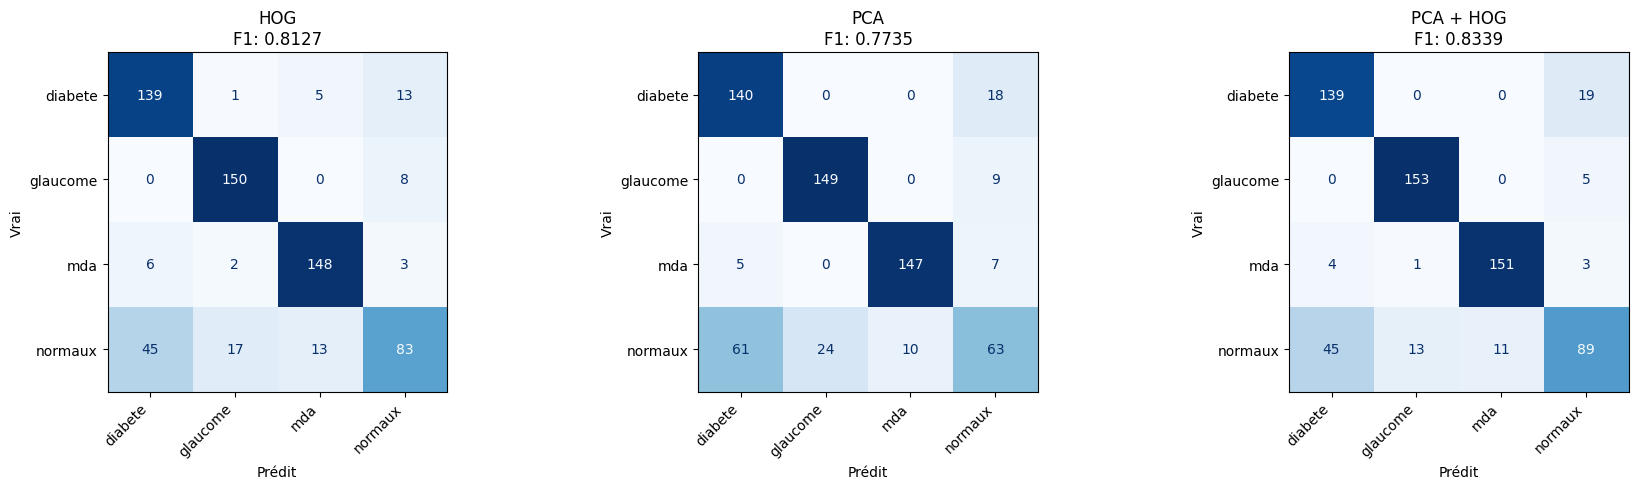

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(results.items()):
    cm = confusion_matrix(y_test, data['y_pred'], labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=axes[idx], values_format='d', cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}\nF1: {data["test_f1"]:.4f}')
    axes[idx].set_xlabel('Prédit')
    axes[idx].set_ylabel('Vrai')
    plt.setp(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

RAPPORT DÉTAILLÉ: PCA + HOG
              precision    recall  f1-score   support

     diabete       0.74      0.88      0.80       158
    glaucome       0.92      0.97      0.94       158
         mda       0.93      0.95      0.94       159
     normaux       0.77      0.56      0.65       158

    accuracy                           0.84       633
   macro avg       0.84      0.84      0.83       633
weighted avg       0.84      0.84      0.83       633



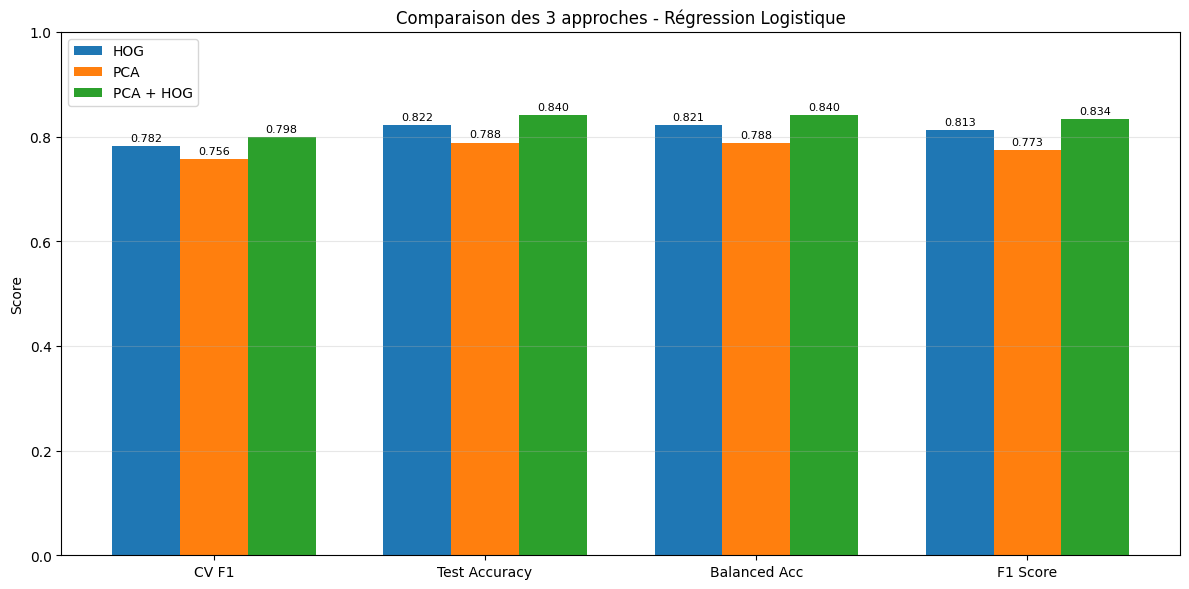

In [14]:
# Rapport détaillé meilleure approche
print(f"RAPPORT DÉTAILLÉ: {best_approach}")
print("="*50)
print(classification_report(y_test, results[best_approach]['y_pred'],
                            target_names=classes, zero_division=0))

# Graphique comparatif
metrics = ['CV F1', 'Test Accuracy', 'Balanced Acc', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, approach in enumerate(results.keys()):
    row = comparison_df[comparison_df['Approche'] == approach].iloc[0]
    values = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, values, width, label=approach)
    for j, v in enumerate(values):
        ax.text(x[j] + i*width, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

ax.set_ylabel('Score')
ax.set_title('Comparaison des 3 approches - Régression Logistique')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()